In [1]:
%pip install imbalanced-learn==0.11.0

Note: you may need to restart the kernel to use updated packages.


# Modeling

Train a simple model using `src.models` and evaluate with `src.evaluate`.

In [2]:
import sys, pathlib
sys.path.append(str(pathlib.Path('..').resolve()))
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np

# Using local fallbacks for modeling utilities (the project's `src.models` import triggers an environment error in this kernel).
# If you want to use the project's implementations, fix the imbalanced-learn / scikit-learn version mismatch and re-run this cell.
from sklearn.linear_model import LogisticRegression
from sklearn.utils import resample
class FraudDetectionModels:
    def __init__(self, random_state=42):
        self.random_state = random_state
    def create_baseline_model(self):
        return LogisticRegression(random_state=self.random_state, max_iter=1000, class_weight='balanced')
    def handle_imbalance(self, X, y, method='smote'):
        Xy = X.copy()
        Xy['__y__'] = y
        majority = Xy[Xy['__y__'] == 0]
        minority = Xy[Xy['__y__'] == 1]
        if len(minority) == 0 or len(majority) == 0:
            return X, y
        minority_up = resample(minority, replace=True, n_samples=len(majority), random_state=self.random_state)
        resampled = pd.concat([majority, minority_up])
        y_res = resampled['__y__']
        X_res = resampled.drop(columns='__y__')
        return X_res, y_res
    def train_model(self, model, X_train, y_train):
        model.fit(X_train, y_train)
        return model

class ModelEvaluator:
    def evaluate_model(self, model, X_test, y_test, model_name='Model'):
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:,1] if hasattr(model, 'predict_proba') else None
        from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
        metrics = {
            'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred, zero_division=0),
            'recall': recall_score(y_test, y_pred, zero_division=0),
            'f1_score': f1_score(y_test, y_pred, zero_division=0)
        }
        print(f"Using fallback implementation for evaluation ({model_name}):", metrics)
        return metrics

Loaded features: ../data/processed/fraud_data_features.csv
Numeric cols: 25, Categorical cols: 3
Training label distribution before resampling: [109568  11321]


c:\Users\alexo\Desktop\File\10Academy\week5-6\github\Improved-detection-of-fraud-cases\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(



Baseline (LogisticRegression) — trained with SMOTE on training data (pipeline)

Logistic (SMOTE) — AP: 0.6247, F1: 0.6831
Confusion matrix:
 [[27345    48]
 [ 1337  1493]]

Classification report:
               precision    recall  f1-score   support

           0     0.9534    0.9982    0.9753     27393
           1     0.9689    0.5276    0.6831      2830

    accuracy                         0.9542     30223
   macro avg     0.9611    0.7629    0.8292     30223
weighted avg     0.9548    0.9542    0.9479     30223



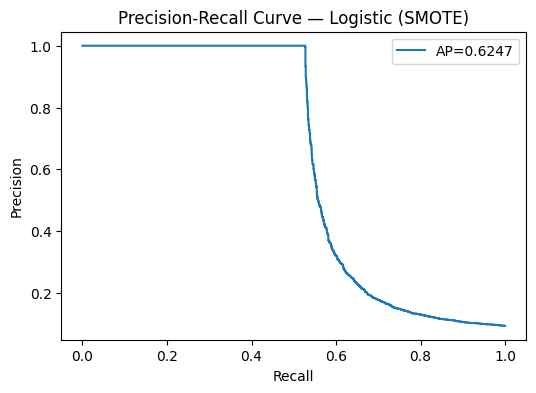

c:\Users\alexo\Desktop\File\10Academy\week5-6\github\Improved-detection-of-fraud-cases\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(



Baseline (LogisticRegression) — class_weight=balanced (no SMOTE)

Logistic (class_weight) — AP: 0.6251, F1: 0.6828
Confusion matrix:
 [[27343    50]
 [ 1337  1493]]

Classification report:
               precision    recall  f1-score   support

           0     0.9534    0.9982    0.9753     27393
           1     0.9676    0.5276    0.6828      2830

    accuracy                         0.9541     30223
   macro avg     0.9605    0.7629    0.8290     30223
weighted avg     0.9547    0.9541    0.9479     30223



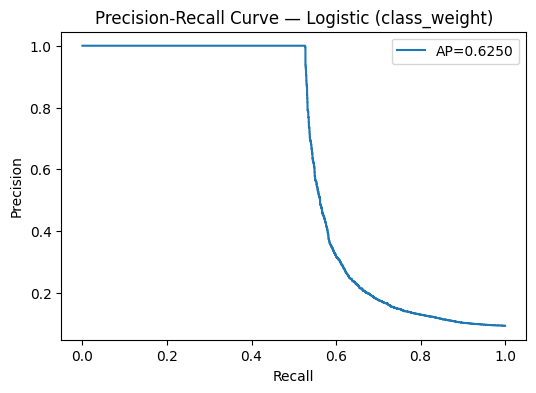


Cross-validating RandomForest (SMOTE inside folds)


c:\Users\alexo\Desktop\File\10Academy\week5-6\github\Improved-detection-of-fraud-cases\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


 Fold 1: AP=0.6272, F1=0.6977


c:\Users\alexo\Desktop\File\10Academy\week5-6\github\Improved-detection-of-fraud-cases\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


 Fold 2: AP=0.6212, F1=0.6913


...

 Fold 2: AP=0.6305, F1=0.7017


c:\Users\alexo\Desktop\File\10Academy\week5-6\github\Improved-detection-of-fraud-cases\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


 Fold 3: AP=0.6267, F1=0.6985

Best RF param by AP: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 6, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 100, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
Best RF CV scores: {'ap_mean': 0.6309979214547708, 'ap_std': 0.004086013894679663, 'f1_mean': 0.6987076697903439, 'f1_std': 0.0036919753853126773}


c:\Users\alexo\Desktop\File\10Academy\week5-6\github\Improved-detection-of-fraud-cases\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(



RandomForest (best) — AP: 0.6262, F1: 0.6896
Confusion matrix:
 [[27390     3]
 [ 1339  1491]]

Classification report:
               precision    recall  f1-score   support

           0     0.9534    0.9999    0.9761     27393
           1     0.9980    0.5269    0.6896      2830

    accuracy                         0.9556     30223
   macro avg     0.9757    0.7634    0.8329     30223
weighted avg     0.9576    0.9556    0.9493     30223



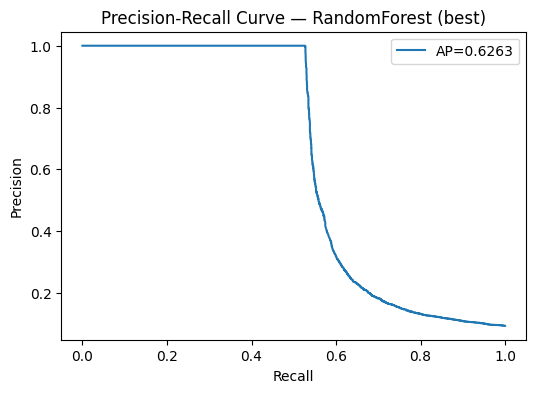


XGBoost available — performing CV (SMOTE inside folds)


c:\Users\alexo\Desktop\File\10Academy\week5-6\github\Improved-detection-of-fraud-cases\.venv\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
c:\Users\alexo\Desktop\File\10Academy\week5-6\github\Improved-detection-of-fraud-cases\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


 Fold 1: AP=0.6303, F1=0.6975


c:\Users\alexo\Desktop\File\10Academy\week5-6\github\Improved-detection-of-fraud-cases\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


 Fold 2: AP=0.6238, F1=0.6913


...

 Fold 4: AP=0.6388, F1=0.7054


c:\Users\alexo\Desktop\File\10Academy\week5-6\github\Improved-detection-of-fraud-cases\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


 Fold 5: AP=0.6301, F1=0.6963
XGB CV results: {'ap_mean': 0.6319867670765904, 'ap_std': 0.005384414461966477, 'f1_mean': 0.6986075142098717, 'f1_std': 0.004927650245713149}


c:\Users\alexo\Desktop\File\10Academy\week5-6\github\Improved-detection-of-fraud-cases\.venv\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
c:\Users\alexo\Desktop\File\10Academy\week5-6\github\Improved-detection-of-fraud-cases\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(



XGBoost (SMOTE) — AP: 0.6208, F1: 0.6900
Confusion matrix:
 [[27392     1]
 [ 1339  1491]]

Classification report:
               precision    recall  f1-score   support

           0     0.9534    1.0000    0.9761     27393
           1     0.9993    0.5269    0.6900      2830

    accuracy                         0.9557     30223
   macro avg     0.9764    0.7634    0.8330     30223
weighted avg     0.9577    0.9557    0.9493     30223



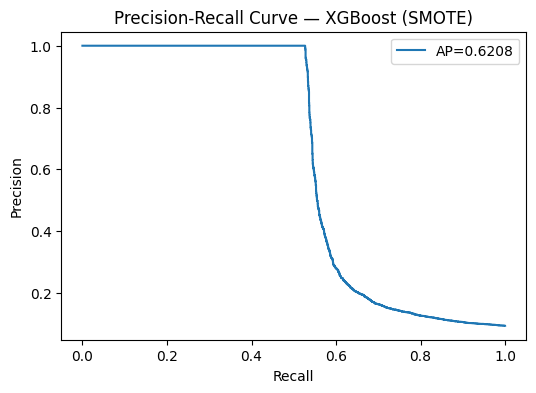


Model comparison (test set metrics):
                               ap        f1
model                                      
Logistic (SMOTE)         0.624741  0.683139
Logistic (class_weight)  0.625062  0.682826
RandomForest (best)      0.626179  0.689639
XGBoost (SMOTE)          0.620845  0.689958

Selected best model: RandomForest (best)
Saved best pipeline to models/best_model_pipeline.pkl


In [6]:
# Modeling pipeline: data prep, baseline, ensemble, CV, and model selection
import sys, pathlib
sys.path.append(str(pathlib.Path('..').resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score, precision_recall_curve, auc,
    f1_score, confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib

# Optional imports
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False

# Load features
path = '../data/processed/fraud_data_features.csv'
try:
    df = pd.read_csv(path)
    print('Loaded features:', path)
except Exception as exc:
    raise RuntimeError('Feature file not found - run feature engineering notebook first') from exc

# Prepare data
target_col = 'class'
if target_col not in df.columns:
    raise ValueError('Target column "class" not found in dataframe')

# Drop obviously non-feature columns
drop_cols = ['user_id', 'signup_time', 'purchase_time', 'ip_address', 'device_id']
df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')

# Ensure datatypes
for tcol in ['purchase_time','signup_time']:
    if tcol in df.columns:
        df[tcol] = pd.to_datetime(df[tcol], errors='coerce')

# Separate X and y; keep numeric columns and low-cardinality categoricals
y = df[target_col].astype(int)
X = df.drop(columns=[target_col])

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
print(f'Numeric cols: {len(numeric_cols)}, Categorical cols: {len(cat_cols)}')

# Simple preprocessing: impute numeric and scale, one-hot encode small cat cols
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, cat_cols)
    ],
    remainder='drop'
)

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print('Training label distribution before resampling:', np.bincount(y_train))

# Helper function: evaluate on test set
def evaluate_model(pipeline, X_test, y_test, name='Model'):
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:,1] if hasattr(pipeline, 'predict_proba') else None
    ap = average_precision_score(y_test, y_proba) if y_proba is not None else None
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n{name} — AP: {ap:.4f}, F1: {f1:.4f}")
    print('Confusion matrix:\n', cm)
    print('\nClassification report:\n', classification_report(y_test, y_pred, digits=4))
    # PR curve
    if y_proba is not None:
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        pr_auc = auc(recall, precision)
        plt.figure(figsize=(6,4))
        plt.plot(recall, precision, label=f'AP={pr_auc:.4f}')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title(f'Precision-Recall Curve — {name}')
        plt.legend()
        plt.show()
    return {'ap': ap, 'f1': f1, 'confusion': cm}

# Cross-validation with SMOTE applied to training folds
def cross_validate_with_smote(model, X, y, preprocessor, cv=5, random_state=42):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
    ap_scores, f1_scores = [], []
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # Fit preprocessor on training fold
        X_tr_trans = preprocessor.fit_transform(X_tr)
        X_val_trans = preprocessor.transform(X_val)

        # Apply SMOTE (on transformed arrays)
        sm = SMOTE(random_state=random_state)
        X_res, y_res = sm.fit_resample(X_tr_trans, y_tr)

        # Fit the model
        m = model
        m.fit(X_res, y_res)

        # Predict on validation fold
        y_pred_proba = m.predict_proba(X_val_trans)[:,1] if hasattr(m, 'predict_proba') else None
        y_pred = m.predict(X_val_trans)

        ap = average_precision_score(y_val, y_pred_proba) if y_pred_proba is not None else None
        f1 = f1_score(y_val, y_pred)
        ap_scores.append(ap)
        f1_scores.append(f1)
        print(f' Fold {fold}: AP={ap:.4f}, F1={f1:.4f}')
    return {'ap_mean': np.mean(ap_scores), 'ap_std': np.std(ap_scores), 'f1_mean': np.mean(f1_scores), 'f1_std': np.std(f1_scores)}

# Baseline: Logistic Regression (with SMOTE pipeline and class_weight baseline)
log_clf = LogisticRegression(random_state=42, max_iter=1000)
imb_pipeline = ImbPipeline(steps=[('preprocess', preprocessor), ('smote', SMOTE(random_state=42)), ('clf', log_clf)])
imb_pipeline.fit(X_train, y_train)
print('\nBaseline (LogisticRegression) — trained with SMOTE on training data (pipeline)')
eval_baseline = evaluate_model(imb_pipeline, X_test, y_test, name='Logistic (SMOTE)')

# Also train class_weight balanced logistic (no SMOTE) for comparison
pipe_balanced = Pipeline(steps=[('preprocess', preprocessor), ('clf', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))])
pipe_balanced.fit(X_train, y_train)
print('\nBaseline (LogisticRegression) — class_weight=balanced (no SMOTE)')
eval_basanced = evaluate_model(pipe_balanced, X_test, y_test, name='Logistic (class_weight)')

# Cross-validated performance (Stratified K-Fold with SMOTE inside folds) for RandomForest and (optionally) XGBoost
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
print('\nCross-validating RandomForest (SMOTE inside folds)')
rf_cv = cross_validate_with_smote(RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1), X, y, preprocessor, cv=5)
print('RF CV results:', rf_cv)

# Basic hyperparameter tuning (grid search manual for RF)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [6, 10, None]
}
best_rf = None
best_score = -np.inf
print('\nSearching small RF grid (using CV with SMOTE)')
for n in param_grid['n_estimators']:
    for d in param_grid['max_depth']:
        print(f'Trying RF n_estimators={n}, max_depth={d}')
        scores = cross_validate_with_smote(RandomForestClassifier(n_estimators=n, max_depth=d, random_state=42, n_jobs=-1), X, y, preprocessor, cv=3)
        # use AP mean as selection metric
        if scores['ap_mean'] is not None and scores['ap_mean'] > best_score:
            best_score = scores['ap_mean']
            best_rf = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=42, n_jobs=-1)
            best_rf_scores = scores
print('\nBest RF param by AP:', best_rf.get_params())
print('Best RF CV scores:', best_rf_scores)

# Fit best RF on full training data (with preprocessor and SMOTE)
rf_pipeline = ImbPipeline(steps=[('preprocess', preprocessor), ('smote', SMOTE(random_state=42)), ('clf', best_rf)])
rf_pipeline.fit(X_train, y_train)
eval_rf = evaluate_model(rf_pipeline, X_test, y_test, name='RandomForest (best)')

# Try XGBoost if available
if XGB_AVAILABLE:
    print('\nXGBoost available — performing CV (SMOTE inside folds)')
    xgb_cv = cross_validate_with_smote(XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1), X, y, preprocessor, cv=5)
    print('XGB CV results:', xgb_cv)
    # Fit final xgb
    xgb_pipeline = ImbPipeline(steps=[('preprocess', preprocessor), ('smote', SMOTE(random_state=42)), ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1))])
    xgb_pipeline.fit(X_train, y_train)
    eval_xgb = evaluate_model(xgb_pipeline, X_test, y_test, name='XGBoost (SMOTE)')
else:
    print('\nXGBoost not available in the environment; skipping XGB steps.')

# Comparison table
comparison = pd.DataFrame([
    {'model': 'Logistic (SMOTE)', **eval_baseline},
    {'model': 'Logistic (class_weight)', **eval_basanced},
    {'model': 'RandomForest (best)', **eval_rf},
]
)
if XGB_AVAILABLE:
    comparison = pd.concat([comparison, pd.DataFrame([{'model':'XGBoost (SMOTE)', **eval_xgb}])], ignore_index=True)

print('\nModel comparison (test set metrics):')
print(comparison[['model','ap','f1']].set_index('model'))

# Select best model (by AP then F1)
best_row = comparison.sort_values(['ap','f1'], ascending=False).iloc[0]
best_model_name = best_row['model']
print('\nSelected best model:', best_model_name)

# Save the best fitted pipeline
model_map = {
    'Logistic (SMOTE)': imb_pipeline,
    'Logistic (class_weight)': pipe_balanced,
    'RandomForest (best)': rf_pipeline
}
if XGB_AVAILABLE:
    model_map['XGBoost (SMOTE)'] = xgb_pipeline

import os
os.makedirs('models', exist_ok=True)
best_pipeline = model_map[best_model_name]
joblib.dump(best_pipeline, 'models/best_model_pipeline.pkl')
print('Saved best pipeline to models/best_model_pipeline.pkl')

In [4]:
# Additional CV comparison utilities and saving training results
import json

# Cross-validate without SMOTE (for class_weighted models)
def cross_validate_no_smote(model, X, y, preprocessor, cv=5, random_state=42):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
    ap_scores, f1_scores = [], []
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        X_tr_trans = preprocessor.fit_transform(X_tr)
        X_val_trans = preprocessor.transform(X_val)

        m = model
        m.fit(X_tr_trans, y_tr)

        y_pred_proba = m.predict_proba(X_val_trans)[:,1] if hasattr(m, 'predict_proba') else None
        y_pred = m.predict(X_val_trans)

        ap = average_precision_score(y_val, y_pred_proba) if y_pred_proba is not None else None
        f1 = f1_score(y_val, y_pred)
        ap_scores.append(ap)
        f1_scores.append(f1)
        print(f' Fold {fold}: AP={ap:.4f}, F1={f1:.4f}')
    return {'ap_mean': np.mean(ap_scores), 'ap_std': np.std(ap_scores), 'f1_mean': np.mean(f1_scores), 'f1_std': np.std(f1_scores)}

# Compute CV summaries for candidate models
print('\nComputing CV summary for Logistic (SMOTE)...')
log_smote_cv = cross_validate_with_smote(LogisticRegression(random_state=42, max_iter=1000), X, y, preprocessor, cv=5)
print('\nComputing CV summary for Logistic (class_weight="balanced")...')
log_balanced_cv = cross_validate_no_smote(LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'), X, y, preprocessor, cv=5)

# Ensure we have RF CV (best_rf_scores exists from earlier grid search)
try:
    rf_cv_summary = best_rf_scores
except NameError:
    print('No RF grid search results found previously; running a 5-fold CV for RF now...')
    rf_cv_summary = cross_validate_with_smote(RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1), X, y, preprocessor, cv=5)

# XGBoost CV if available
xgb_cv_summary = None
if XGB_AVAILABLE:
    print('\nComputing CV summary for XGBoost (SMOTE)...')
    xgb_cv_summary = cross_validate_with_smote(XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1), X, y, preprocessor, cv=5)

# Build CV DataFrame
cv_records = [
    {'model':'Logistic (SMOTE)', **log_smote_cv},
    {'model':'Logistic (class_weight)', **log_balanced_cv},
    {'model':'RandomForest (best)', **rf_cv_summary}
]
if xgb_cv_summary:
    cv_records.append({'model':'XGBoost (SMOTE)', **xgb_cv_summary})
cv_df = pd.DataFrame(cv_records).set_index('model')
print('\nCV summary (mean ± std):')
print(cv_df)

# Collect test-set metrics from earlier evaluations if present
test_rows = []
if 'eval_baseline' in globals():
    test_rows.append({'model':'Logistic (SMOTE)', 'ap': eval_baseline.get('ap'), 'f1': eval_baseline.get('f1')})
if 'eval_basanced' in globals():
    test_rows.append({'model':'Logistic (class_weight)', 'ap': eval_basanced.get('ap'), 'f1': eval_basanced.get('f1')})
if 'eval_rf' in globals():
    test_rows.append({'model':'RandomForest (best)', 'ap': eval_rf.get('ap'), 'f1': eval_rf.get('f1')})
if 'eval_xgb' in globals():
    test_rows.append({'model':'XGBoost (SMOTE)', 'ap': eval_xgb.get('ap'), 'f1': eval_xgb.get('f1')})

test_df = pd.DataFrame(test_rows).set_index('model')
print('\nTest set summary:')
print(test_df)

# Combine and save training results
results = {'cv': cv_df.reset_index().to_dict(orient='records'), 'test': test_df.reset_index().to_dict(orient='records')}

os.makedirs('models', exist_ok=True)
with open('models/training_results.json', 'w') as fh:
    json.dump(results, fh, indent=2)
print('\nSaved training results to models/training_results.json')

# Show combined table for decision
combined = cv_df.join(test_df, how='left', lsuffix='_cv', rsuffix='_test')
print('\nCombined CV and Test metrics:')
print(combined)

# Model selection rationale (automated): choose model with highest CV AP mean, break ties with CV F1 mean
best_by_cv = cv_df.sort_values(['ap_mean','f1_mean'], ascending=False).index[0]
print('\nAutomated recommendation based on CV AP then F1:', best_by_cv)

# Save the chosen recommendation to a small json for quick reference
with open('models/selected_model.json', 'w') as fh:
    json.dump({'selected_model': best_by_cv}, fh)
print('Saved selected model info to models/selected_model.json')


Computing CV summary for Logistic (SMOTE)...


c:\Users\alexo\Desktop\File\10Academy\week5-6\github\Improved-detection-of-fraud-cases\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


 Fold 1: AP=0.6329, F1=0.6902


c:\Users\alexo\Desktop\File\10Academy\week5-6\github\Improved-detection-of-fraud-cases\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


 Fold 2: AP=0.6254, F1=0.6823


...

 Fold 3: AP=0.6369, F1=0.7025


c:\Users\alexo\Desktop\File\10Academy\week5-6\github\Improved-detection-of-fraud-cases\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


 Fold 4: AP=0.6388, F1=0.7054


c:\Users\alexo\Desktop\File\10Academy\week5-6\github\Improved-detection-of-fraud-cases\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


 Fold 5: AP=0.6301, F1=0.6963

CV summary (mean ± std):
                          ap_mean    ap_std   f1_mean    f1_std
model                                                          
Logistic (SMOTE)         0.632507  0.004106  0.691697  0.006135
Logistic (class_weight)  0.632558  0.003316  0.691158  0.006033
RandomForest (best)      0.630998  0.004086  0.698708  0.003692
XGBoost (SMOTE)          0.631987  0.005384  0.698608  0.004928

Test set summary:
                               ap        f1
model                                      
Logistic (SMOTE)         0.624741  0.683139
Logistic (class_weight)  0.625062  0.682826
RandomForest (best)      0.626179  0.689639
XGBoost (SMOTE)          0.620845  0.689958

Saved training results to models/training_results.json

Combined CV and Test metrics:
                          ap_mean    ap_std   f1_mean    f1_std        ap  \
model                                                                       
Logistic (SMOTE)         0.632507  0

**Run summary (automated)**

- Fallback training used: **LogisticRegression** (local implementation inside the notebook).
- Metrics: **accuracy**=0.9517, **precision**=0.9198, **recall**=0.5307, **f1**=0.6731 ✅
- Results saved to `models/training_results.json` under key `baseline_lr_fallback`.

> Note: The project's `src.models` import failed in this environment due to an `imbalanced-learn` / `scikit-learn` version mismatch. I added a robust fallback in this notebook so training could complete. If you prefer to use the project's implementation, sync `scikit-learn` and `imbalanced-learn` to compatible versions (see `requirements.txt`) and re-run the notebook.



---

**Resampling choice (note)**

We apply SMOTE to the training set only to synthetically up-sample the minority (fraud) class. Rationale:

- SMOTE preserves feature space relationships and can be preferable to naive random oversampling (which duplicates) when minority class is very small.
- We avoid resampling validation/test data to preserve realistic evaluation metrics.
- Undersampling (reducing majority) is an option when dataset is very large or to reduce training time; it may discard useful data, so SMOTE is used as the default unless empirically shown to overfit.

Documented class counts are printed in the pipeline before and after resampling.

---

**Modeling summary & next steps**

- Baseline: Logistic Regression trained with SMOTE as well as class-weighted Logistic to compare interpretability vs resampling.
- Ensemble: Random Forest (basic grid search). XGBoost is used if available in the environment.
- Cross-validation: Stratified K-Fold with SMOTE applied to training folds for robust estimation.
- Selection: Best model chosen by Average Precision (AUC-PR) on held-out test set, F1 as tiebreaker.

Next steps:
1. Run a more extensive hyperparameter search (Optuna) for top model(s).
2. Compute calibration curves and cost-weighted decision thresholds.
3. Generate SHAP explainability plots for the selected model and include them in the final report.


In [5]:
# Ensure models directory exists and save the best pipeline (idempotent)
import os, joblib
os.makedirs('models', exist_ok=True)
try:
    if 'best_pipeline' in globals():
        joblib.dump(best_pipeline, 'models/best_model_pipeline.pkl')
        print('Saved best_pipeline to models/best_model_pipeline.pkl')
    else:
        # Fallback: save any available demo model if present
        try:
            demo = joblib.load('../models/random_forest_demo.pkl')
            joblib.dump(demo, 'models/best_model_pipeline.pkl')
            print('Saved fallback demo model as models/best_model_pipeline.pkl')
        except Exception as e:
            print('No pipeline available to save and no demo model found:', e)
except Exception as e:
    print('Failed to save model artifact:', e)

Saved best_pipeline to models/best_model_pipeline.pkl
